In [9]:
from pathlib import Path
import json, math
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def aggregate_results_by_P_kappa(dk_folder_path, results_filename="training_results.json"):
    """
    Reads `training_results.json` and aggregates by (P, kappa_0).
    NOTE: test MSE is converted to 1/2·MSE for aggregation.

    Returns a dict keyed by (P, kappa) with:
      - mean_testmse: mean of 1/2·MSE
      - errorofthemeantestmse: SEM of 1/2·MSE
      - mean_mS_final, errorofthemean_mS_final
      - n: number of runs
    """
    dk_folder_path = Path(dk_folder_path)

    # Find the results JSON
    json_path = dk_folder_path / results_filename
    if not json_path.exists():
        matches = list(dk_folder_path.rglob(results_filename))
        if not matches:
            raise FileNotFoundError(f"Could not find '{results_filename}' under {dk_folder_path}")
        json_path = matches[0]

    # Load JSON list
    with open(json_path, "r") as f:
        data = json.load(f)

    # Group values by (P, kappa)
    buckets = defaultdict(lambda: {"test_mse_half": [], "final_mS": []})

    for r in data:
        # Skip incomplete or non-trained entries robustly
        if r.get("status") and r["status"] != "trained":
            continue

        try:
            P = int(r["P"])
            kappa = float(r.get("kappa_0", r.get("kappa")))
            # Prefer already-logged half-MSE if present; otherwise scale here.
            if "test_half_mse" in r:  # optional alternative key
                test_mse_half = float(r["test_half_mse"])
            else:
                test_mse_half = 0.5 * float(r["test_mse"])
            final_mS = float(r.get("final_eval_mS", r.get("final_mS")))
        except (KeyError, TypeError, ValueError):
            continue

        if math.isnan(test_mse_half) or math.isnan(final_mS):
            continue

        buckets[(P, kappa)]["test_mse_half"].append(test_mse_half)
        buckets[(P, kappa)]["final_mS"].append(final_mS)

    # Aggregate
    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["test_mse_half"], dtype=float)
        mS_vals = np.asarray(vals["final_mS"], dtype=float)
        n = int(half_mse_vals.size)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": float(half_mse_vals.mean()) if n else float('nan'),  # 1/2·MSE
            "errorofthemeantestmse": _sem(half_mse_vals),                        # SEM(1/2·MSE)
            "mean_mS_final": float(mS_vals.mean()) if n else float('nan'),
            "errorofthemean_mS_final": _sem(mS_vals),
            "n": n,
        }

    return out

# --- Example usage ---
results1 = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4")
results = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Index/results/2009_d18_k2_p4_g0.5_fin_2/d18_k2")
#results = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4")

from pprint import pprint; pprint(results)


{(50, 1e-05): {'P': 50,
               'errorofthemean_mS_final': 0.2693374151673605,
               'errorofthemeantestmse': 21.57258532246264,
               'kappa': 1e-05,
               'mean_mS_final': -0.1020251028239727,
               'mean_testmse': 35.631012201309204,
               'n': 4},
 (50, 0.0001): {'P': 50,
                'errorofthemean_mS_final': 0.26929099611500323,
                'errorofthemeantestmse': 21.57388622621458,
                'kappa': 0.0001,
                'mean_mS_final': -0.10126681812107563,
                'mean_testmse': 35.65095043182373,
                'n': 4},
 (50, 0.001): {'P': 50,
               'errorofthemean_mS_final': 0.2736850326359899,
               'errorofthemeantestmse': 21.53673036567732,
               'kappa': 0.001,
               'mean_mS_final': -0.08633702993392944,
               'mean_testmse': 35.871824502944946,
               'n': 4},
 (50, 0.01): {'P': 50,
              'errorofthemean_mS_final': 0.317919639087

[saved] /home/goring/mean_field_langevin/plots/plots_4/heat1_index.svg


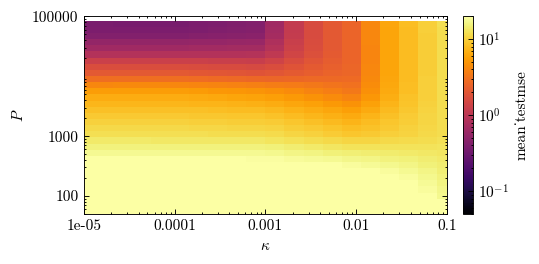

In [10]:
# --- Flexible heatmap with smoothing options (upsample/gouraud) ------------
from pathlib import Path
import sys
import math
from typing import Optional, Tuple, Sequence, Union
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, LinearSegmentedColormap  # <-- added

PLOT_UTILS_DIR = "/home/goring/mean_field_langevin/plots_utils"  # where slim_plotters.py lives

def _apply_slim_style(theme: str = "light", serif: bool = True) -> None:
    """Try to apply your SLIM plotting style; fall back silently if missing."""
    try:
        if PLOT_UTILS_DIR not in sys.path:
            sys.path.insert(0, PLOT_UTILS_DIR)
        from slim_plotters import apply  # type: ignore
        apply(theme=theme, serif=serif)
    except Exception as e:
        print(f"[note] slim_plotters not applied ({e}); using Matplotlib defaults.)")

def _edges_from_centers(centers: np.ndarray, log: bool = False) -> np.ndarray:
    """Compute pixel edges from sorted center coordinates (linear or log)."""
    centers = np.asarray(centers, dtype=float)
    centers = np.sort(centers)
    n = centers.size
    if n == 1:
        c = centers[0]
        if log and c > 0:
            return np.array([c/np.sqrt(10.0), c*np.sqrt(10.0)])
        delta = 0.5 if c == 0 else 0.5 * abs(c)
        return np.array([c - delta, c + delta])

    if log and np.any(centers <= 0):
        log = False  # can't do log edges with nonpositive centers

    edges = np.empty(n + 1, dtype=float)
    if log:
        mids = np.sqrt(centers[:-1] * centers[1:])
        edges[1:-1] = mids
        r0 = centers[1] / centers[0]
        r1 = centers[-1] / centers[-2]
        edges[0] = centers[0] / np.sqrt(r0)
        edges[-1] = centers[-1] * np.sqrt(r1)
    else:
        mids = 0.5 * (centers[:-1] + centers[1:])
        edges[1:-1] = mids
        edges[0]  = centers[0] - (mids[0] - centers[0])
        edges[-1] = centers[-1] + (centers[-1] - mids[-1])
    return edges

def _bilinear_upsample(
    Z: np.ndarray,
    xcenters: np.ndarray,
    ycenters: np.ndarray,
    refine: Union[int, Tuple[int, int]],
    xlog: bool,
    ylog: bool,
):
    """
    Upsample Z defined on a rectangular grid of centers (y, x) via separable 1D linear
    interpolation along x then y. Interpolates in log-coordinates if xlog/ylog True.
    """
    Z = np.asarray(Z, dtype=float)
    ycenters = np.asarray(ycenters, dtype=float)
    xcenters = np.asarray(xcenters, dtype=float)

    if isinstance(refine, int):
        ry = rx = max(1, int(refine))
    else:
        ry = max(1, int(refine[0])); rx = max(1, int(refine[1]))

    # Coordinates for interpolation (in axis space where spacing is uniform)
    xcoord = np.log(xcenters) if xlog else xcenters
    ycoord = np.log(ycenters) if ylog else ycenters

    # New, denser coordinates across the same span
    x_new = np.linspace(xcoord.min(), xcoord.max(), num=Z.shape[1] * rx)
    y_new = np.linspace(ycoord.min(), ycoord.max(), num=Z.shape[0] * ry)

    # Interpolate along x for each row
    Zx = np.empty((Z.shape[0], x_new.size), dtype=float)
    for i in range(Z.shape[0]):
        Zx[i, :] = np.interp(x_new, xcoord, Z[i, :])

    # Interpolate along y for each column
    Zxy = np.empty((y_new.size, x_new.size), dtype=float)
    for j in range(Zx.shape[1]):
        Zxy[:, j] = np.interp(y_new, ycoord, Zx[:, j])

    # Map coordinates back to original axis scale
    xcent_new = np.exp(x_new) if xlog else x_new
    ycent_new = np.exp(y_new) if ylog else y_new

    return Zxy, xcent_new, ycent_new

def _cell_to_vertex_values(Z: np.ndarray) -> np.ndarray:
    """
    Convert cell-centered (Ny, Nx) values to vertex-centered (Ny+1, Nx+1)
    by averaging adjacent cells (edges/corners handled with available neighbors).
    Useful for Gouraud shading (vertex colors).
    """
    Ny, Nx = Z.shape
    V = np.empty((Ny + 1, Nx + 1), dtype=float)

    # interior
    V[1:Ny, 1:Nx] = 0.25 * (Z[:-1, :-1] + Z[1:, :-1] + Z[:-1, 1:] + Z[1:, 1:])

    # edges
    V[0, 1:Nx]      = 0.5 * (Z[0, :-1] + Z[0, 1:])            # top edge
    V[Ny, 1:Nx]     = 0.5 * (Z[-1, :-1] + Z[-1, 1:])          # bottom edge
    V[1:Ny, 0]      = 0.5 * (Z[:-1, 0] + Z[1:, 0])            # left edge
    V[1:Ny, Nx]     = 0.5 * (Z[:-1, -1] + Z[1:, -1])          # right edge

    # corners
    V[0, 0]         = Z[0, 0]
    V[0, Nx]        = Z[0, -1]
    V[Ny, 0]        = Z[-1, 0]
    V[Ny, Nx]       = Z[-1, -1]

    return V

def heatmap_from_agg_dict(
    agg_dict: dict,
    *,
    value_key: str = "mean_testmse",
    # --- colormap control ---
    predefined_cmap: Optional[str] = "inferno",   # e.g. "inferno"; if None, use custom_hex_colors
    custom_hex_colors: Optional[Tuple[str, str]] = None,  # two hex colors if predefined_cmap=None
    # --- figure/axes ---
    figsize: Tuple[float, float] = (4.8, 3.6),
    aspect: Union[str, float] = "auto",
    xlog: bool = False,
    ylog: bool = False,
    clog: bool = False,                  # log color scale
    vmin: Optional[float] = None,        # colorbar min
    vmax: Optional[float] = None,        # colorbar max
    xlim: Optional[Tuple[float, float]] = None,  # x-axis [min, max]
    ylim: Optional[Tuple[float, float]] = None,  # y-axis [min, max]
    sort_P_ascending: bool = True,
    sort_kappa_ascending: bool = True,
    xticks: Optional[Sequence[float]] = None,
    yticks: Optional[Sequence[float]] = None,
    xtick_labels: Optional[Sequence[str]] = None,
    ytick_labels: Optional[Sequence[str]] = None,
    smooth: str = "none",                 # "none", "upsample", "gouraud"
    refine: Union[int, Tuple[int, int]] = 4,
    save_path: Optional[str] = None,      # can be ".../plot.svg"
    theme: str = "light",
    serif: bool = True,
):
    """
    Build a heatmap from an aggregated dict. X = kappa, Y = P, cell = agg[value_key].

    Smoothing options:
      - smooth="none"     : original blocky heatmap
      - smooth="upsample" : bilinear upsampling (control smoothness via `refine`)
      - smooth="gouraud"  : Gouraud vertex shading (no `refine` needed)

    Scales: x/y/log color scales supported.
    Limits: set colorbar with vmin/vmax; axes with xlim/ylim.
    Colormap:
      - If `predefined_cmap` is a string (e.g. "inferno"), that is used.
      - If `predefined_cmap` is None, provide `custom_hex_colors=(hex1, hex2)` to build a
        continuous two-color map.
    """
    _apply_slim_style(theme=theme, serif=serif)

    # Collect (P, kappa, value)
    records = []
    for k, v in agg_dict.items():
        if isinstance(k, tuple) and len(k) == 2:
            P, kappa = k
        else:
            P = v.get("P")
            kappa = v.get("kappa")
        if P is None or kappa is None or value_key not in v:
            continue
        try:
            P = int(P); kappa = float(kappa); val = float(v[value_key])
        except (TypeError, ValueError):
            continue
        if math.isnan(val):
            continue
        records.append((P, kappa, val))

    if not records:
        raise ValueError(f"No usable entries for value_key='{value_key}'.")

    # Unique sorted axes
    Ps = sorted({r[0] for r in records}, reverse=not sort_P_ascending)
    kappas = sorted({r[1] for r in records}, reverse=not sort_kappa_ascending)

    # Build Z with running means in case of duplicates
    Z = np.full((len(Ps), len(kappas)), np.nan, dtype=float)
    counts = np.zeros_like(Z, dtype=int)
    p_index = {p: i for i, p in enumerate(Ps)}
    k_index = {k0: j for j, k0 in enumerate(kappas)}
    for P, k0, val in records:
        i = p_index[P]; j = k_index[k0]
        if np.isnan(Z[i, j]):
            Z[i, j] = val; counts[i, j] = 1
        else:
            Z[i, j] = (Z[i, j] * counts[i, j] + val) / (counts[i, j] + 1)
            counts[i, j] += 1

    # Axis centers (as actual coordinates)
    xcenters = np.asarray(kappas, dtype=float)
    ycenters = np.asarray(Ps, dtype=float)

    # Optional smoothing
    method = smooth.lower().strip()
    if method == "upsample":
        Zplot, xcent_plot, ycent_plot = _bilinear_upsample(
            Z, xcenters, ycenters, refine=refine, xlog=xlog, ylog=ylog
        )
        xedges = _edges_from_centers(xcent_plot, log=xlog)
        yedges = _edges_from_centers(ycent_plot, log=ylog)
        C_for_plot = np.ma.masked_invalid(Zplot)
        use_gouraud = False
        Xmesh = Ymesh = None
    elif method == "gouraud":
        # Need vertex coordinates and vertex colors
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        Xmesh, Ymesh = np.meshgrid(xedges, yedges)
        C_for_plot = _cell_to_vertex_values(Z)  # (Ny+1, Nx+1)
        use_gouraud = True
    else:  # "none"
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        C_for_plot = np.ma.masked_invalid(Z)
        use_gouraud = False
        Xmesh = Ymesh = None

    # ----- Colormap selection -----
    if predefined_cmap is not None:
        cmap_obj = plt.get_cmap(predefined_cmap)
    else:
        if not (isinstance(custom_hex_colors, (tuple, list)) and len(custom_hex_colors) == 2):
            raise ValueError("predefined_cmap=None requires custom_hex_colors=(hex1, hex2).")
        cmap_obj = LinearSegmentedColormap.from_list(
            "custom_2color", list(custom_hex_colors), N=256
        )

    # ----- Color normalization (colorbar min/max come from vmin/vmax) -----
    if clog:
        # LogNorm needs strictly positive vmin
        if vmin is None:
            flat = np.asarray(C_for_plot).ravel()
            positive = flat[np.isfinite(flat) & (flat > 0)]
            if positive.size == 0:
                raise ValueError("clog=True but all values are <= 0 or NaN.")
            vmin_use = float(positive.min())
        else:
            vmin_use = float(vmin)
        vmax_use = float(np.nanmax(C_for_plot)) if vmax is None else float(vmax)
        norm = LogNorm(vmin=vmin_use, vmax=vmax_use)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if use_gouraud:
        mesh = ax.pcolormesh(Xmesh, Ymesh, C_for_plot, cmap=cmap_obj, norm=norm, shading="gouraud")
    else:
        mesh = ax.pcolormesh(xedges, yedges, C_for_plot, cmap=cmap_obj, norm=norm, shading="auto")

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_key, labelpad=4)

    # Axes config
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$P$")

    # Axis limits (only if provided)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_aspect(aspect)
    ax.grid(False)

    # Ticks: explicit if provided, otherwise use centers
    def _fmt_kappa(x: float) -> str:
        return f"{x:.2g}" if (abs(x) < 1e-2 or abs(x) >= 1e2) else f"{x:g}"

    # X ticks (kappa)
    if xticks is None:
        xt = xcenters
        xlabels = [_fmt_kappa(x) for x in xcenters]
    else:
        xt = np.asarray(list(xticks), dtype=float)
        if xlog: xt = xt[xt > 0]
        xlabels = list(xtick_labels) if xtick_labels is not None else [_fmt_kappa(x) for x in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xlabels)

    # Y ticks (P)
    if yticks is None:
        yt = ycenters
        ylabels = [str(int(y)) for y in ycenters]
    else:
        yt = np.asarray(list(yticks), dtype=float)
        if ylog: yt = yt[yt > 0]
        ylabels = list(ytick_labels) if ytick_labels is not None else [str(int(y)) for y in yt]
    ax.set_yticks(yt)
    ax.set_yticklabels(ylabels)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    return fig, ax, {
        "Z": Z, "Ps": Ps, "kappas": kappas, "counts": counts,
        "method": method, "refine": refine
    }


# ------------------------- Example usage -------------------------
# Pick ONE of the following examples.

# A) Predefined colormap (inferno) + explicit limits + SVG save
fig, ax, meta = heatmap_from_agg_dict(
    results,
    value_key="mean_testmse",
    predefined_cmap="inferno",
    figsize=(5.0, 2.5),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=5e-2, vmax=20,            # colorbar limits
    xlim=(1e-5, 0.1),               # x-axis limits
    ylim=(50, 75000),               # y-axis limits
    smooth="upsample", refine=4,
    xticks=[1e-5,1e-4,1e-3, 1e-2, 1e-1], yticks=[1e2, 1e3, 1e5],
    save_path="/home/goring/mean_field_langevin/plots/plots_4/heat1_index.svg"    # SVG output
)
plt.show()

# B) Two custom hex colors -> continuous colormap





[saved] /home/goring/mean_field_langevin/plots/plots_4/heat1.svg


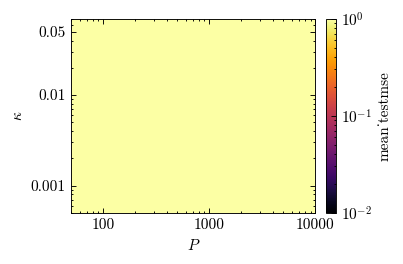

TypeError: heatmap_from_agg_dict() missing 1 required positional argument: 'agg_dict'

In [ ]:
# --- Flexible heatmap with smoothing options (upsample/gouraud) ------------
from pathlib import Path
import sys
import math
from typing import Optional, Tuple, Sequence, Union
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, LinearSegmentedColormap  # <-- added

PLOT_UTILS_DIR = "/home/goring/mean_field_langevin/plots_utils"  # where slim_plotters.py lives

def _apply_slim_style(theme: str = "light", serif: bool = True) -> None:
    """Try to apply your SLIM plotting style; fall back silently if missing."""
    try:
        if PLOT_UTILS_DIR not in sys.path:
            sys.path.insert(0, PLOT_UTILS_DIR)
        from slim_plotters import apply  # type: ignore
        apply(theme=theme, serif=serif)
    except Exception as e:
        print(f"[note] slim_plotters not applied ({e}); using Matplotlib defaults.)")

def _edges_from_centers(centers: np.ndarray, log: bool = False) -> np.ndarray:
    """Compute pixel edges from sorted center coordinates (linear or log)."""
    centers = np.asarray(centers, dtype=float)
    centers = np.sort(centers)
    n = centers.size
    if n == 1:
        c = centers[0]
        if log and c > 0:
            return np.array([c/np.sqrt(10.0), c*np.sqrt(10.0)])
        delta = 0.5 if c == 0 else 0.5 * abs(c)
        return np.array([c - delta, c + delta])

    if log and np.any(centers <= 0):
        log = False  # can't do log edges with nonpositive centers

    edges = np.empty(n + 1, dtype=float)
    if log:
        mids = np.sqrt(centers[:-1] * centers[1:])
        edges[1:-1] = mids
        r0 = centers[1] / centers[0]
        r1 = centers[-1] / centers[-2]
        edges[0] = centers[0] / np.sqrt(r0)
        edges[-1] = centers[-1] * np.sqrt(r1)
    else:
        mids = 0.5 * (centers[:-1] + centers[1:])
        edges[1:-1] = mids
        edges[0]  = centers[0] - (mids[0] - centers[0])
        edges[-1] = centers[-1] + (centers[-1] - mids[-1])
    return edges

def _bilinear_upsample(
    Z: np.ndarray,
    xcenters: np.ndarray,
    ycenters: np.ndarray,
    refine: Union[int, Tuple[int, int]],
    xlog: bool,
    ylog: bool,
):
    """
    Upsample Z defined on a rectangular grid of centers (y, x) via separable 1D linear
    interpolation along x then y. Interpolates in log-coordinates if xlog/ylog True.
    """
    Z = np.asarray(Z, dtype=float)
    ycenters = np.asarray(ycenters, dtype=float)
    xcenters = np.asarray(xcenters, dtype=float)

    if isinstance(refine, int):
        ry = rx = max(1, int(refine))
    else:
        ry = max(1, int(refine[0])); rx = max(1, int(refine[1]))

    # Coordinates for interpolation (in axis space where spacing is uniform)
    xcoord = np.log(xcenters) if xlog else xcenters
    ycoord = np.log(ycenters) if ylog else ycenters

    # New, denser coordinates across the same span
    x_new = np.linspace(xcoord.min(), xcoord.max(), num=Z.shape[1] * rx)
    y_new = np.linspace(ycoord.min(), ycoord.max(), num=Z.shape[0] * ry)

    # Interpolate along x for each row
    Zx = np.empty((Z.shape[0], x_new.size), dtype=float)
    for i in range(Z.shape[0]):
        Zx[i, :] = np.interp(x_new, xcoord, Z[i, :])

    # Interpolate along y for each column
    Zxy = np.empty((y_new.size, x_new.size), dtype=float)
    for j in range(Zx.shape[1]):
        Zxy[:, j] = np.interp(y_new, ycoord, Zx[:, j])

    # Map coordinates back to original axis scale
    xcent_new = np.exp(x_new) if xlog else x_new
    ycent_new = np.exp(y_new) if ylog else y_new

    return Zxy, xcent_new, ycent_new

def _cell_to_vertex_values(Z: np.ndarray) -> np.ndarray:
    """
    Convert cell-centered (Ny, Nx) values to vertex-centered (Ny+1, Nx+1)
    by averaging adjacent cells (edges/corners handled with available neighbors).
    Useful for Gouraud shading (vertex colors).
    """
    Ny, Nx = Z.shape
    V = np.empty((Ny + 1, Nx + 1), dtype=float)

    # interior
    V[1:Ny, 1:Nx] = 0.25 * (Z[:-1, :-1] + Z[1:, :-1] + Z[:-1, 1:] + Z[1:, 1:])

    # edges
    V[0, 1:Nx]      = 0.5 * (Z[0, :-1] + Z[0, 1:])            # top edge
    V[Ny, 1:Nx]     = 0.5 * (Z[-1, :-1] + Z[-1, 1:])          # bottom edge
    V[1:Ny, 0]      = 0.5 * (Z[:-1, 0] + Z[1:, 0])            # left edge
    V[1:Ny, Nx]     = 0.5 * (Z[:-1, -1] + Z[1:, -1])          # right edge

    # corners
    V[0, 0]         = Z[0, 0]
    V[0, Nx]        = Z[0, -1]
    V[Ny, 0]        = Z[-1, 0]
    V[Ny, Nx]       = Z[-1, -1]

    return V

def heatmap_from_agg_dict(
    agg_dict: dict,
    *,
    value_key: str = "mean_testmse",
    # --- colormap control ---
    predefined_cmap: Optional[str] = "inferno",   # e.g. "inferno"; if None, use custom_hex_colors
    custom_hex_colors: Optional[Tuple[str, str]] = None,  # two hex colors if predefined_cmap=None
    # --- figure/axes ---
    figsize: Tuple[float, float] = (4.8, 3.6),
    aspect: Union[str, float] = "auto",
    xlog: bool = False,
    ylog: bool = False,
    clog: bool = False,                  # log color scale
    vmin: Optional[float] = None,        # colorbar min
    vmax: Optional[float] = None,        # colorbar max
    xlim: Optional[Tuple[float, float]] = None,  # x-axis [min, max]
    ylim: Optional[Tuple[float, float]] = None,  # y-axis [min, max]
    sort_P_ascending: bool = True,
    sort_kappa_ascending: bool = True,
    xticks: Optional[Sequence[float]] = None,
    yticks: Optional[Sequence[float]] = None,
    xtick_labels: Optional[Sequence[str]] = None,
    ytick_labels: Optional[Sequence[str]] = None,
    smooth: str = "none",                 # "none", "upsample", "gouraud"
    refine: Union[int, Tuple[int, int]] = 4,
    save_path: Optional[str] = None,      # can be ".../plot.svg"
    theme: str = "light",
    serif: bool = True,
):
    """
    Build a heatmap from an aggregated dict. X = P, Y = kappa, cell = agg[value_key].

    Smoothing options:
      - smooth="none"     : original blocky heatmap
      - smooth="upsample" : bilinear upsampling (control smoothness via `refine`)
      - smooth="gouraud"  : Gouraud vertex shading (no `refine` needed)

    Scales: x/y/log color scales supported.
    Limits: set colorbar with vmin/vmax; axes with xlim/ylim.
    Colormap:
      - If `predefined_cmap` is a string (e.g. "inferno"), that is used.
      - If `predefined_cmap` is None, provide `custom_hex_colors=(hex1, hex2)` to build a
        continuous two-color map.
    """
    _apply_slim_style(theme=theme, serif=serif)

    # Collect (P, kappa, value)
    records = []
    for k, v in agg_dict.items():
        if isinstance(k, tuple) and len(k) == 2:
            P, kappa = k
        else:
            P = v.get("P")
            kappa = v.get("kappa")
        if P is None or kappa is None or value_key not in v:
            continue
        try:
            P = int(P); kappa = float(kappa); val = float(v[value_key])
        except (TypeError, ValueError):
            continue
        if math.isnan(val):
            continue
        records.append((P, kappa, val))

    if not records:
        raise ValueError(f"No usable entries for value_key='{value_key}'.")

    # Unique sorted axes
    Ps = sorted({r[0] for r in records}, reverse=not sort_P_ascending)
    kappas = sorted({r[1] for r in records}, reverse=not sort_kappa_ascending)

    # Build Z with running means in case of duplicates
    Z = np.full((len(Ps), len(kappas)), np.nan, dtype=float)
    counts = np.zeros_like(Z, dtype=int)
    p_index = {p: i for i, p in enumerate(Ps)}
    k_index = {k0: j for j, k0 in enumerate(kappas)}
    for P, k0, val in records:
        i = p_index[P]; j = k_index[k0]
        if np.isnan(Z[i, j]):
            Z[i, j] = val; counts[i, j] = 1
        else:
            Z[i, j] = (Z[i, j] * counts[i, j] + val) / (counts[i, j] + 1)
            counts[i, j] += 1

    # Axis centers (as actual coordinates) -- SWAPPED: x = Ps, y = kappas
    xcenters = np.asarray(Ps, dtype=float)
    ycenters = np.asarray(kappas, dtype=float)

    # Optional smoothing (note the transpose so rows correspond to y=kappa)
    method = smooth.lower().strip()
    if method == "upsample":
        Zplot, xcent_plot, ycent_plot = _bilinear_upsample(
            Z.T, xcenters, ycenters, refine=refine, xlog=xlog, ylog=ylog
        )
        xedges = _edges_from_centers(xcent_plot, log=xlog)
        yedges = _edges_from_centers(ycent_plot, log=ylog)
        C_for_plot = np.ma.masked_invalid(Zplot)
        use_gouraud = False
        Xmesh = Ymesh = None
    elif method == "gouraud":
        # Need vertex coordinates and vertex colors
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        Xmesh, Ymesh = np.meshgrid(xedges, yedges)
        C_for_plot = _cell_to_vertex_values(Z.T)  # (Ny+1, Nx+1) with y=kappa, x=P
        use_gouraud = True
    else:  # "none"
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        C_for_plot = np.ma.masked_invalid(Z.T)
        use_gouraud = False
        Xmesh = Ymesh = None

    # ----- Colormap selection -----
    if predefined_cmap is not None:
        cmap_obj = plt.get_cmap(predefined_cmap)
    else:
        if not (isinstance(custom_hex_colors, (tuple, list)) and len(custom_hex_colors) == 2):
            raise ValueError("predefined_cmap=None requires custom_hex_colors=(hex1, hex2).")
        cmap_obj = LinearSegmentedColormap.from_list(
            "custom_2color", list(custom_hex_colors), N=256
        )

    # ----- Color normalization (colorbar min/max come from vmin/vmax) -----
    if clog:
        # LogNorm needs strictly positive vmin
        if vmin is None:
            flat = np.asarray(C_for_plot).ravel()
            positive = flat[np.isfinite(flat) & (flat > 0)]
            if positive.size == 0:
                raise ValueError("clog=True but all values are <= 0 or NaN.")
            vmin_use = float(positive.min())
        else:
            vmin_use = float(vmin)
        vmax_use = float(np.nanmax(C_for_plot)) if vmax is None else float(vmax)
        norm = LogNorm(vmin=vmin_use, vmax=vmax_use)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if use_gouraud:
        mesh = ax.pcolormesh(Xmesh, Ymesh, C_for_plot, cmap=cmap_obj, norm=norm, shading="gouraud")
    else:
        mesh = ax.pcolormesh(xedges, yedges, C_for_plot, cmap=cmap_obj, norm=norm, shading="auto")

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_key, labelpad=4)

    # Axes config
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(r"$P$")
    ax.set_ylabel(r"$\kappa$")

    # Axis limits (only if provided)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_aspect(aspect)
    ax.grid(False)

    # Ticks: explicit if provided, otherwise use centers
    def _fmt_kappa(x: float) -> str:
        return f"{x:.2g}" if (abs(x) < 1e-2 or abs(x) >= 1e2) else f"{x:g}"

    # X ticks (P)
    if xticks is None:
        xt = xcenters
        xlabels = [str(int(x)) for x in xcenters]
    else:
        xt = np.asarray(list(xticks), dtype=float)
        if xlog: xt = xt[xt > 0]
        xlabels = list(xtick_labels) if xtick_labels is not None else [str(int(x)) for x in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xlabels)

    # Y ticks (kappa)
    if yticks is None:
        yt = ycenters
        ylabels = [_fmt_kappa(y) for y in ycenters]
    else:
        yt = np.asarray(list(yticks), dtype=float)
        if ylog: yt = yt[yt > 0]
        ylabels = list(ytick_labels) if ytick_labels is not None else [_fmt_kappa(y) for y in yt]
    ax.set_yticks(yt)
    ax.set_yticklabels(ylabels)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    return fig, ax, {
        "Z": Z, "Ps": Ps, "kappas": kappas, "counts": counts,
        "method": method, "refine": refine
    }


# ------------------------- Example usage -------------------------
# Pick ONE of the following examples.

# A) Predefined colormap (inferno) + explicit limits + SVG save
fig, ax, meta = heatmap_from_agg_dict(
    results,
    value_key="mean_testmse",
    predefined_cmap="inferno",
    figsize=(3.75, 2.5),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2, vmax=1,            # colorbar limits
    xlim=(50, 10000),             # x-axis limits (now P)
    ylim=(5e-4, 0.07),            # y-axis limits (now kappa)
    smooth="upsample", refine=4,
    xticks=[1e2, 1e3, 1e4], yticks=[1e-3, 1e-2, 5e-2],
    save_path="/home/goring/mean_field_langevin/plots/plots_4/heat1.svg"    # SVG output
)
plt.show()


fig, ax, meta = heatmap_from_agg_dict(
      # SVG output
)
plt.show()
# B) Two custom hex colors -> continuous colormap


In [ ]:
from pathlib import Path
import json, math, re
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def _safe_float(x, default=float('nan')):
    try:
        return float(x)
    except Exception:
        return default

def _parse_P_kappa_from_filename(name: str):
    """
    Extract P and kappa from filenames like:
      rs_aw_..._P10000_kap1.000e-01_..._Ptr10000_..._kap7.500e-02_...
    Priority:
      1) Ptr{P}
      2) first standalone _P{int}_ (not Peval)
      3) first kap{number}
    """
    P = None
    m_ptr = re.search(r'Ptr(\d+)', name)
    if m_ptr:
        P = int(m_ptr.group(1))
    else:
        m_p = re.search(r'(?<!Peval)(?:^|_)P(\d+)(?=_)', name)
        if m_p:
            P = int(m_p.group(1))

    kappa = float('nan')
    m_k = re.search(r'kap([+\-]?\d*\.?\d+(?:[eE][+\-]?\d+)?)', name)
    if m_k:
        kappa = _safe_float(m_k.group(1))
    return P, kappa

def _final_half_mse_from_traj(traj: dict):
    """
    Prefer traj['half_mse_empirical'] last (already 1/2·MSE on held-out).
    Fallbacks: half_mse_total_ms, mean(last half_mse_empirical_per_exp), and
    finally 0.5 * last train_mse.
    """
    def last_of(x):
        if isinstance(x, list) and x:
            return x[-1]
        return x

    v = last_of(traj.get('half_mse_empirical'))
    if isinstance(v, (float, int)):
        return float(v)

    v = last_of(traj.get('half_mse_total_ms'))
    if isinstance(v, (float, int)):
        return float(v)

    per_exp = traj.get('half_mse_empirical_per_exp')
    if isinstance(per_exp, list) and per_exp:
        last = per_exp[-1]
        try:
            arr = np.asarray(last, dtype=float)
            if arr.size:
                return float(np.mean(arr))
        except Exception:
            pass

    tm = last_of(traj.get('train_mse'))
    if isinstance(tm, (float, int)):
        return 0.5 * float(tm)  # ensure HALF MSE units

    return float('nan')

def _final_mS_scalar_from_traj(traj: dict):
    """
    'm_S' last entry; average across modes if it's a list.
    """
    mS_hist = traj.get('m_S')
    if not isinstance(mS_hist, list) or not mS_hist:
        return float('nan')
    last = mS_hist[-1]
    if isinstance(last, (float, int)):
        return float(last)
    try:
        arr = np.asarray(last, dtype=float)
        if arr.size:
            return float(np.mean(arr))
    except Exception:
        pass
    return float('nan')

def _fill_nan_one(x):
    try:
        xf = float(x)
        if math.isnan(xf) or math.isinf(xf):
            return 1.0
        return xf
    except Exception:
        # if it wasn't a float, just return as-is
        return x

def aggregate_rs_results_by_P_kappa(root_dir, filename_glob="**/*.json"):
    """
    Walks `root_dir` recursively, loads run JSONs from the RS cavity script,
    aggregates by (P, kappa), and replaces any NaN/inf outputs with 1.0.
    """
    root = Path(root_dir)
    files = list(root.glob(filename_glob))

    buckets = defaultdict(lambda: {"half_mse": [], "mS": []})

    for fp in files:
        if not fp.name.endswith(".json"):
            continue
        try:
            with open(fp, "r") as f:
                payload = json.load(f)
        except Exception:
            continue

        traj = payload.get("traj", {})
        cfg = payload.get("config", {})

        # kappa: prefer config, else filename
        kappa = _safe_float(cfg.get("kappa"))
        P, kappa_from_name = _parse_P_kappa_from_filename(fp.name)
        if math.isnan(kappa) or not isinstance(kappa, float):
            kappa = kappa_from_name

        if P is None or (kappa is None) or math.isnan(float(kappa)):
            continue

        half_mse = _final_half_mse_from_traj(traj)
        mS = _final_mS_scalar_from_traj(traj)

        if not math.isnan(half_mse):
            buckets[(P, float(kappa))]["half_mse"].append(float(half_mse))
        if not math.isnan(mS):
            buckets[(P, float(kappa))]["mS"].append(float(mS))

    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["half_mse"], dtype=float)
        mS_vals = np.asarray(vals["mS"], dtype=float)

        n = int(half_mse_vals.size)  # n is based on half_mse count

        mean_half = float(half_mse_vals.mean()) if n else float('nan')
        sem_half = _sem(half_mse_vals) if n else float('nan')

        # mS could be missing even if half_mse exists
        if mS_vals.size:
            mean_mS = float(mS_vals.mean())
            sem_mS = _sem(mS_vals)
        else:
            mean_mS = float('nan')
            sem_mS = float('nan')

        # Replace NaN/inf with 1.0 as requested
        mean_half = _fill_nan_one(mean_half)
        sem_half = _fill_nan_one(sem_half)
        mean_mS = _fill_nan_one(mean_mS)
        sem_mS = _fill_nan_one(sem_mS)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": mean_half,                 # already 1/2·MSE
            "errorofthemeantestmse": sem_half,         # SEM(1/2·MSE)
            "mean_mS_final": mean_mS,
            "errorofthemean_mS_final": sem_mS,
            "n": n,
        }

    return out

# --- Example usage ---
if __name__ == "__main__":
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm"
    )
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_new/alltest"
    )
    results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/Index/results/2009_MF_d18_k2_p4_a=0.1_correct")
    from pprint import pprint
    pprint(results2)


{(10000, 1e-05): {'P': 10000,
                  'errorofthemean_mS_final': 1.0,
                  'errorofthemeantestmse': 1.0,
                  'kappa': 1e-05,
                  'mean_mS_final': 1.0,
                  'mean_testmse': 10.861668586730957,
                  'n': 1},
 (10000, 0.0001): {'P': 10000,
                   'errorofthemean_mS_final': 1.0,
                   'errorofthemeantestmse': 1.0,
                   'kappa': 0.0001,
                   'mean_mS_final': 1.0,
                   'mean_testmse': 11.4002685546875,
                   'n': 1},
 (10000, 0.001): {'P': 10000,
                  'errorofthemean_mS_final': 1.0,
                  'errorofthemeantestmse': 1.0,
                  'kappa': 0.001,
                  'mean_mS_final': 1.0,
                  'mean_testmse': 12.14076042175293,
                  'n': 1},
 (10000, 0.01): {'P': 10000,
                 'errorofthemean_mS_final': 1.0,
                 'errorofthemeantestmse': 1.0,
                 'kap

In [1]:
from pathlib import Path
import json, math, re
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def _safe_float(x, default=float('nan')):
    try:
        return float(x)
    except Exception:
        return default

def _parse_P_kappa_from_filename(name: str):
    """
    Extract P and kappa from filenames like:
      rs_aw_..._P10000_kap1.000e-01_..._Ptr10000_..._kap7.500e-02_...
    Priority:
      1) Ptr{P}
      2) first standalone _P{int}_ (not Peval)
      3) first kap{number}
    """
    P = None
    m_ptr = re.search(r'Ptr(\d+)', name)
    if m_ptr:
        P = int(m_ptr.group(1))
    else:
        m_p = re.search(r'(?<!Peval)(?:^|_)P(\d+)(?=_)', name)
        if m_p:
            P = int(m_p.group(1))

    kappa = float('nan')
    m_k = re.search(r'kap([+\-]?\d*\.?\d+(?:[eE][+\-]?\d+)?)', name)
    if m_k:
        kappa = _safe_float(m_k.group(1))
    return P, kappa

def _last_list(traj: dict, key: str):
    """Return the last list entry in traj[key] if it exists and is a list; else None."""
    v = traj.get(key)
    if isinstance(v, list) and v:
        last = v[-1]
        if isinstance(last, list):
            return last
    return None

def _final_half_mse_scalar(traj: dict):
    """Scalar fallback for 1/2·MSE if per-exp values are unavailable."""
    def last_of(x):
        if isinstance(x, list) and x:
            return x[-1]
        return x
    v = last_of(traj.get('half_mse_empirical'))
    if isinstance(v, (float, int)):
        return float(v)
    v = last_of(traj.get('half_mse_total_ms'))
    if isinstance(v, (float, int)):
        return float(v)
    per_exp = _last_list(traj, 'half_mse_empirical_per_exp')
    if isinstance(per_exp, list) and per_exp:
        try:
            arr = np.asarray(per_exp, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size:
                return float(np.mean(arr))
        except Exception:
            pass
    tm = last_of(traj.get('train_mse'))
    if isinstance(tm, (float, int)):
        return 0.5 * float(tm)
    return float('nan')

def _final_mS_per_exp(traj: dict):
    """
    Return per-experiment m_S scalars at the final log step, averaging across modes per exp.
    -> list[float] or []
    """
    mS_logs = traj.get('m_S_per_exp')
    if not isinstance(mS_logs, list) or not mS_logs:
        return []
    last = mS_logs[-1]  # shape ~ [E][M] (lists)
    out = []
    if isinstance(last, list):
        for modes in last:
            if isinstance(modes, list) and modes:
                arr = np.asarray(modes, dtype=float)
                arr = arr[np.isfinite(arr)]
                if arr.size:
                    out.append(float(np.mean(arr)))
    return out

def _final_half_mse_per_exp(traj: dict):
    """
    Return per-experiment final 1/2·MSE values if present, else [].
    """
    vals = _last_list(traj, 'half_mse_empirical_per_exp')
    if not isinstance(vals, list) or not vals:
        return []
    arr = np.asarray(vals, dtype=float)
    arr = arr[np.isfinite(arr)]
    return [float(x) for x in arr]

def aggregate_rs_results_by_P_kappa(root_dir, filename_glob="**/*.json"):
    """
    Walk `root_dir` recursively, loads run JSONs from the RS cavity script,
    aggregates by (P, kappa). Means are over all *per-experiment* finals across files.
    SEM uses ddof=1 and is left as NaN when n<=1 (no 1.0 forcing).
    """
    root = Path(root_dir)
    files = list(root.glob(filename_glob))

    buckets = defaultdict(lambda: {"half_mse_vals": [], "mS_vals": []})

    for fp in files:
        if not fp.name.endswith(".json"):
            continue
        try:
            with open(fp, "r") as f:
                payload = json.load(f)
        except Exception:
            continue

        traj = payload.get("traj", {})
        cfg = payload.get("config", {})

        # kappa: prefer config, else filename
        kappa = _safe_float(cfg.get("kappa"))
        P, kappa_from_name = _parse_P_kappa_from_filename(fp.name)
        if math.isnan(kappa) or not isinstance(kappa, float):
            kappa = kappa_from_name

        if P is None or (kappa is None) or math.isnan(float(kappa)):
            continue

        # --- 1/2·MSE per-exp replicates if available, else scalar fallback
        per_exp_half = _final_half_mse_per_exp(traj)
        if per_exp_half:
            buckets[(P, float(kappa))]["half_mse_vals"].extend(per_exp_half)
        else:
            v = _final_half_mse_scalar(traj)
            if math.isfinite(v):
                buckets[(P, float(kappa))]["half_mse_vals"].append(v)

        # --- m_S per-exp (avg across modes) if available, else scalar fallback
        per_exp_mS = _final_mS_per_exp(traj)
        if per_exp_mS:
            buckets[(P, float(kappa))]["mS_vals"].extend(per_exp_mS)
        else:
            # try scalar m_S fallback
            mS_hist = traj.get('m_S')
            if isinstance(mS_hist, list) and mS_hist:
                last = mS_hist[-1]
                if isinstance(last, (float, int)) and math.isfinite(last):
                    buckets[(P, float(kappa))]["mS_vals"].append(float(last))
                elif isinstance(last, list) and last:
                    arr = np.asarray(last, dtype=float)
                    arr = arr[np.isfinite(arr)]
                    if arr.size:
                        buckets[(P, float(kappa))]["mS_vals"].append(float(arr.mean()))

    out = {}
    for (P, kappa), vals in buckets.items():
        half_arr = np.asarray(vals["half_mse_vals"], dtype=float)
        half_arr = half_arr[np.isfinite(half_arr)]
        mS_arr = np.asarray(vals["mS_vals"], dtype=float)
        mS_arr = mS_arr[np.isfinite(mS_arr)]

        n = int(half_arr.size)  # n based on half_mse replicates actually used

        mean_half = float(np.mean(half_arr)) if n else float('nan')
        sem_half  = _sem(half_arr) if n else float('nan')

        if mS_arr.size:
            mean_mS = float(np.mean(mS_arr))
            sem_mS  = _sem(mS_arr)
        else:
            mean_mS = float('nan')
            sem_mS  = float('nan')

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": mean_half,                 # this is 1/2·MSE on held-out
            "errorofthemeantestmse": sem_half,         # SEM(1/2·MSE)
            "mean_mS_final": mean_mS,                  # avg across modes then across exps/files
            "errorofthemean_mS_final": sem_mS,         # SEM over exps/files
            "n": n,                                    # total per-exp replicates used
        }

    return out

if __name__ == "__main__":
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm"
    )
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_new/alltest"
    )
    results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_ard=4_fin")
    from pprint import pprint
    pprint(results2)
    results_MFa = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/Index/results/2009_MF_d18_k2_p4_a=0.1_correct2")
    from pprint import pprint
    pprint(results_MFa)


{(10, 0.0005): {'P': 10,
                'errorofthemean_mS_final': 0.0003730292207471254,
                'errorofthemeantestmse': 0.030984817654712362,
                'kappa': 0.0005,
                'mean_mS_final': 0.001284568919800222,
                'mean_testmse': 0.7288308447459713,
                'n': 3},
 (10, 0.001): {'P': 10,
               'errorofthemean_mS_final': 0.00039219796821126935,
               'errorofthemeantestmse': 0.03106280658291968,
               'kappa': 0.001,
               'mean_mS_final': 0.0012615449571361144,
               'mean_testmse': 0.7284737500206878,
               'n': 3},
 (10, 0.005): {'P': 10,
               'errorofthemean_mS_final': 0.00041501529673753404,
               'errorofthemeantestmse': 0.022482416681989584,
               'kappa': 0.005,
               'mean_mS_final': 0.001300065137911588,
               'mean_testmse': 0.738800750754308,
               'n': 3},
 (10, 0.0075): {'P': 10,
                'errorofthemean_m

In [4]:
from pathlib import Path
import json, math, re
from collections import defaultdict
from typing import Dict, Tuple
import numpy as np

# ------------------------- helpers -------------------------

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def _safe_float(x, default=float('nan')):
    try:
        return float(x)
    except Exception:
        return default

def _parse_P_kappa_from_filename(name: str):
    """
    Extract P and kappa from filenames like:
      rs_aw_ard_sgld_FAST_..._Ptr10000_..._Peval100000_..._kap1.000e-02_...
    Priority:
      1) Ptr{P}
      2) first standalone _P{int}_ (not Peval)
      3) first kap{number}
    """
    P = None
    m_ptr = re.search(r'Ptr(\d+)', name)
    if m_ptr:
        P = int(m_ptr.group(1))
    else:
        m_p = re.search(r'(?<!Peval)(?:^|_)P(\d+)(?=_)', name)
        if m_p:
            P = int(m_p.group(1))

    kappa = float('nan')
    m_k = re.search(r'kap([+\-]?\d*\.?\d+(?:[eE][+\-]?\d+)?)', name)
    if m_k:
        try:
            kappa = float(m_k.group(1))
        except Exception:
            kappa = float('nan')
    return P, kappa

def _last_list(traj: dict, key: str):
    """Return the last list entry in traj[key] if it exists and is a list; else None."""
    v = traj.get(key)
    if isinstance(v, list) and v:
        last = v[-1]
        if isinstance(last, list):
            return last
    return None

def _final_eval_mse_full_per_exp(traj: dict):
    """
    Return the final per-experiment FULL-eval MSE values if present, else [].
    """
    vals = _last_list(traj, 'eval_mse_full_per_exp')
    if not isinstance(vals, list) or not vals:
        return []
    arr = np.asarray(vals, dtype=float)
    arr = arr[np.isfinite(arr)]
    return [float(x) for x in arr]

def _final_eval_mse_full_scalar(traj: dict, summary: dict):
    """
    Scalar fallback for FULL-eval MSE when per-exp values are unavailable.
    """
    # Try traj['eval_mse_full'] last scalar
    vlist = traj.get('eval_mse_full')
    if isinstance(vlist, list) and vlist:
        try:
            v = float(vlist[-1])
            if math.isfinite(v):
                return v
        except Exception:
            pass
    # Try summary['test_mse_full'] (present on early stop & final save)
    v = summary.get('test_mse_full') or summary.get('eval_mse_full')
    v = _safe_float(v)
    return v if math.isfinite(v) else float('nan')

# ------------------------- main aggregator -------------------------

def aggregate_evalmse_by_P_kappa(root_dir, filename_glob="**/*.json") -> Dict[Tuple[int, float], dict]:
    """
    Walk `root_dir` recursively, load training JSONs, aggregate by (P, kappa).
    For each file:
      - Prefer the last 'eval_mse_full_per_exp' (list over E experiments).
      - Else fall back to the last scalar 'eval_mse_full' (traj) or summary['test_mse_full'].
    Then compute mean across all per-exp values pooled across files for the same (P, kappa).
    Returns a dict keyed by (P, kappa) with fields:
      - 'mean_testmse' (this is MSE, not 1/2·MSE)
      - 'errorofthemeantestmse' (SEM over pooled replicates)
      - 'n' (replicate count used)
      - 'P', 'kappa' (echoed for convenience)
    """
    root = Path(root_dir)
    files = list(root.glob(filename_glob))

    buckets = defaultdict(lambda: {"vals": []})

    for fp in files:
        if not fp.name.endswith(".json"):
            continue
        try:
            with open(fp, "r") as f:
                payload = json.load(f)
        except Exception:
            continue

        traj = payload.get("traj", {}) or {}
        summary = payload.get("summary", {}) or {}
        cfg = payload.get("config", {}) or {}

        # --- Parse (P, kappa)
        kappa = _safe_float(cfg.get("kappa"))
        P, kappa_from_name = _parse_P_kappa_from_filename(fp.name)
        if math.isnan(kappa):
            kappa = kappa_from_name

        if P is None or (kappa is None) or math.isnan(float(kappa)):
            # Try a last-ditch attempt: maybe tag "P{P}_" appears at start
            m_tagP = re.search(r'(?:^|_)P(\d+)(?:_|$)', fp.stem)
            if m_tagP and P is None:
                P = int(m_tagP.group(1))
            if P is None or math.isnan(float(kappa)):
                continue  # skip if still unresolved

        # --- Pull per-exp FULL eval-MSE if available; else scalar fallback
        per_exp_full = _final_eval_mse_full_per_exp(traj)
        if per_exp_full:
            buckets[(P, float(kappa))]["vals"].extend(per_exp_full)
        else:
            v = _final_eval_mse_full_scalar(traj, summary)
            if math.isfinite(v):
                buckets[(P, float(kappa))]["vals"].append(float(v))

    # --- Reduce
    out = {}
    for (P, kappa), vals in buckets.items():
        arr = np.asarray(vals["vals"], dtype=float)
        arr = arr[np.isfinite(arr)]
        n = int(arr.size)
        mean_mse = float(np.mean(arr)) if n else float('nan')
        sem_mse  = _sem(arr) if n else float('nan')

        out[(P, kappa)] = {
            "P": P,
            "kappa": float(kappa),
            "mean_testmse": mean_mse,                 # note: this is MSE (FULL eval)
            "errorofthemeantestmse": sem_mse,         # SEM over pooled replicates
            "n": n,                                   
        }

    return out

# ------------------------- example usage -------------------------

    # Point this to the directory that contains your saved JSON runs
root = "/home/goring/mean_field_langevin/Index/results/2009_MF_d18_k2_p4_a=0.1_correct2"
results_idx = aggregate_evalmse_by_P_kappa(root)
print(results_idx)
    

{(1000, 0.1): {'P': 1000, 'kappa': 0.1, 'mean_testmse': 25.62547254562378, 'errorofthemeantestmse': 1.6693438429683956, 'n': 4}, (50000, 0.1): {'P': 50000, 'kappa': 0.1, 'mean_testmse': 23.838088989257812, 'errorofthemeantestmse': 0.46412225141573415, 'n': 4}, (75000, 0.1): {'P': 75000, 'kappa': 0.1, 'mean_testmse': 23.42042350769043, 'errorofthemeantestmse': 0.6507965969471434, 'n': 4}, (100, 0.1): {'P': 100, 'kappa': 0.1, 'mean_testmse': 24.90110445022583, 'errorofthemeantestmse': 1.4516088247711207, 'n': 4}, (25000, 0.1): {'P': 25000, 'kappa': 0.1, 'mean_testmse': 22.86539649963379, 'errorofthemeantestmse': 1.041796046767626, 'n': 4}, (50, 0.1): {'P': 50, 'kappa': 0.1, 'mean_testmse': 24.231593132019043, 'errorofthemeantestmse': 0.9961081095716805, 'n': 4}, (10000, 0.1): {'P': 10000, 'kappa': 0.1, 'mean_testmse': 26.059288024902344, 'errorofthemeantestmse': 1.269318883858923, 'n': 4}, (1000, 1e-05): {'P': 1000, 'kappa': 1e-05, 'mean_testmse': 9.038891077041626, 'errorofthemeantestms

[saved] /home/goring/mean_field_langevin/plots/plots_4/heat2_index.svg


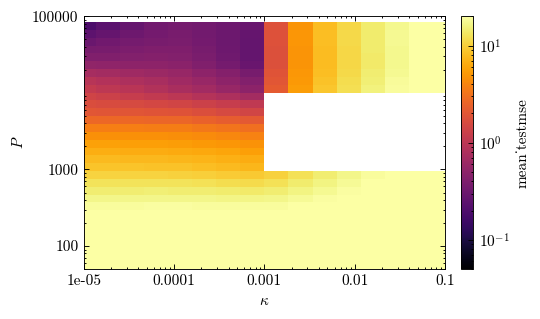

In [8]:
# --- Flexible heatmap with smoothing options (upsample/gouraud) ------------
from pathlib import Path
import sys
import math
from typing import Optional, Tuple, Sequence, Union
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, LinearSegmentedColormap  # <-- added

PLOT_UTILS_DIR = "/home/goring/mean_field_langevin/plots_utils"  # where slim_plotters.py lives

def _apply_slim_style(theme: str = "light", serif: bool = True) -> None:
    """Try to apply your SLIM plotting style; fall back silently if missing."""
    try:
        if PLOT_UTILS_DIR not in sys.path:
            sys.path.insert(0, PLOT_UTILS_DIR)
        from slim_plotters import apply  # type: ignore
        apply(theme=theme, serif=serif)
    except Exception as e:
        print(f"[note] slim_plotters not applied ({e}); using Matplotlib defaults.)")

def _edges_from_centers(centers: np.ndarray, log: bool = False) -> np.ndarray:
    """Compute pixel edges from sorted center coordinates (linear or log)."""
    centers = np.asarray(centers, dtype=float)
    centers = np.sort(centers)
    n = centers.size
    if n == 1:
        c = centers[0]
        if log and c > 0:
            return np.array([c/np.sqrt(10.0), c*np.sqrt(10.0)])
        delta = 0.5 if c == 0 else 0.5 * abs(c)
        return np.array([c - delta, c + delta])

    if log and np.any(centers <= 0):
        log = False  # can't do log edges with nonpositive centers

    edges = np.empty(n + 1, dtype=float)
    if log:
        mids = np.sqrt(centers[:-1] * centers[1:])
        edges[1:-1] = mids
        r0 = centers[1] / centers[0]
        r1 = centers[-1] / centers[-2]
        edges[0] = centers[0] / np.sqrt(r0)
        edges[-1] = centers[-1] * np.sqrt(r1)
    else:
        mids = 0.5 * (centers[:-1] + centers[1:])
        edges[1:-1] = mids
        edges[0]  = centers[0] - (mids[0] - centers[0])
        edges[-1] = centers[-1] + (centers[-1] - mids[-1])
    return edges

def _bilinear_upsample(
    Z: np.ndarray,
    xcenters: np.ndarray,
    ycenters: np.ndarray,
    refine: Union[int, Tuple[int, int]],
    xlog: bool,
    ylog: bool,
):
    """
    Upsample Z defined on a rectangular grid of centers (y, x) via separable 1D linear
    interpolation along x then y. Interpolates in log-coordinates if xlog/ylog True.
    """
    Z = np.asarray(Z, dtype=float)
    ycenters = np.asarray(ycenters, dtype=float)
    xcenters = np.asarray(xcenters, dtype=float)

    if isinstance(refine, int):
        ry = rx = max(1, int(refine))
    else:
        ry = max(1, int(refine[0])); rx = max(1, int(refine[1]))

    # Coordinates for interpolation (in axis space where spacing is uniform)
    xcoord = np.log(xcenters) if xlog else xcenters
    ycoord = np.log(ycenters) if ylog else ycenters

    # New, denser coordinates across the same span
    x_new = np.linspace(xcoord.min(), xcoord.max(), num=Z.shape[1] * rx)
    y_new = np.linspace(ycoord.min(), ycoord.max(), num=Z.shape[0] * ry)

    # Interpolate along x for each row
    Zx = np.empty((Z.shape[0], x_new.size), dtype=float)
    for i in range(Z.shape[0]):
        Zx[i, :] = np.interp(x_new, xcoord, Z[i, :])

    # Interpolate along y for each column
    Zxy = np.empty((y_new.size, x_new.size), dtype=float)
    for j in range(Zx.shape[1]):
        Zxy[:, j] = np.interp(y_new, ycoord, Zx[:, j])

    # Map coordinates back to original axis scale
    xcent_new = np.exp(x_new) if xlog else x_new
    ycent_new = np.exp(y_new) if ylog else y_new

    return Zxy, xcent_new, ycent_new

def _cell_to_vertex_values(Z: np.ndarray) -> np.ndarray:
    """
    Convert cell-centered (Ny, Nx) values to vertex-centered (Ny+1, Nx+1)
    by averaging adjacent cells (edges/corners handled with available neighbors).
    Useful for Gouraud shading (vertex colors).
    """
    Ny, Nx = Z.shape
    V = np.empty((Ny + 1, Nx + 1), dtype=float)

    # interior
    V[1:Ny, 1:Nx] = 0.25 * (Z[:-1, :-1] + Z[1:, :-1] + Z[:-1, 1:] + Z[1:, 1:])

    # edges
    V[0, 1:Nx]      = 0.5 * (Z[0, :-1] + Z[0, 1:])            # top edge
    V[Ny, 1:Nx]     = 0.5 * (Z[-1, :-1] + Z[-1, 1:])          # bottom edge
    V[1:Ny, 0]      = 0.5 * (Z[:-1, 0] + Z[1:, 0])            # left edge
    V[1:Ny, Nx]     = 0.5 * (Z[:-1, -1] + Z[1:, -1])          # right edge

    # corners
    V[0, 0]         = Z[0, 0]
    V[0, Nx]        = Z[0, -1]
    V[Ny, 0]        = Z[-1, 0]
    V[Ny, Nx]       = Z[-1, -1]

    return V

def heatmap_from_agg_dict(
    agg_dict: dict,
    *,
    value_key: str = "mean_testmse",
    # --- colormap control ---
    predefined_cmap: Optional[str] = "inferno",   # e.g. "inferno"; if None, use custom_hex_colors
    custom_hex_colors: Optional[Tuple[str, str]] = None,  # two hex colors if predefined_cmap=None
    # --- figure/axes ---
    figsize: Tuple[float, float] = (4.8, 3.6),
    aspect: Union[str, float] = "auto",
    xlog: bool = False,
    ylog: bool = False,
    clog: bool = False,                  # log color scale
    vmin: Optional[float] = None,        # colorbar min
    vmax: Optional[float] = None,        # colorbar max
    xlim: Optional[Tuple[float, float]] = None,  # x-axis [min, max]
    ylim: Optional[Tuple[float, float]] = None,  # y-axis [min, max]
    sort_P_ascending: bool = True,
    sort_kappa_ascending: bool = True,
    xticks: Optional[Sequence[float]] = None,
    yticks: Optional[Sequence[float]] = None,
    xtick_labels: Optional[Sequence[str]] = None,
    ytick_labels: Optional[Sequence[str]] = None,
    smooth: str = "none",                 # "none", "upsample", "gouraud"
    refine: Union[int, Tuple[int, int]] = 4,
    save_path: Optional[str] = None,      # can be ".../plot.svg"
    theme: str = "light",
    serif: bool = True,
):
    """
    Build a heatmap from an aggregated dict. X = kappa, Y = P, cell = agg[value_key].

    Smoothing options:
      - smooth="none"     : original blocky heatmap
      - smooth="upsample" : bilinear upsampling (control smoothness via `refine`)
      - smooth="gouraud"  : Gouraud vertex shading (no `refine` needed)

    Scales: x/y/log color scales supported.
    Limits: set colorbar with vmin/vmax; axes with xlim/ylim.
    Colormap:
      - If `predefined_cmap` is a string (e.g. "inferno"), that is used.
      - If `predefined_cmap` is None, provide `custom_hex_colors=(hex1, hex2)` to build a
        continuous two-color map.
    """
    _apply_slim_style(theme=theme, serif=serif)

    # Collect (P, kappa, value)
    records = []
    for k, v in agg_dict.items():
        if isinstance(k, tuple) and len(k) == 2:
            P, kappa = k
        else:
            P = v.get("P")
            kappa = v.get("kappa")
        if P is None or kappa is None or value_key not in v:
            continue
        try:
            P = int(P); kappa = float(kappa); val = float(v[value_key])
        except (TypeError, ValueError):
            continue
        if math.isnan(val):
            continue
        records.append((P, kappa, val))

    if not records:
        raise ValueError(f"No usable entries for value_key='{value_key}'.")

    # Unique sorted axes
    Ps = sorted({r[0] for r in records}, reverse=not sort_P_ascending)
    kappas = sorted({r[1] for r in records}, reverse=not sort_kappa_ascending)

    # Build Z with running means in case of duplicates
    Z = np.full((len(Ps), len(kappas)), np.nan, dtype=float)
    counts = np.zeros_like(Z, dtype=int)
    p_index = {p: i for i, p in enumerate(Ps)}
    k_index = {k0: j for j, k0 in enumerate(kappas)}
    for P, k0, val in records:
        i = p_index[P]; j = k_index[k0]
        if np.isnan(Z[i, j]):
            Z[i, j] = val; counts[i, j] = 1
        else:
            Z[i, j] = (Z[i, j] * counts[i, j] + val) / (counts[i, j] + 1)
            counts[i, j] += 1

    # Axis centers (as actual coordinates)
    xcenters = np.asarray(kappas, dtype=float)
    ycenters = np.asarray(Ps, dtype=float)

    # Optional smoothing
    method = smooth.lower().strip()
    if method == "upsample":
        Zplot, xcent_plot, ycent_plot = _bilinear_upsample(
            Z, xcenters, ycenters, refine=refine, xlog=xlog, ylog=ylog
        )
        xedges = _edges_from_centers(xcent_plot, log=xlog)
        yedges = _edges_from_centers(ycent_plot, log=ylog)
        C_for_plot = np.ma.masked_invalid(Zplot)
        use_gouraud = False
        Xmesh = Ymesh = None
    elif method == "gouraud":
        # Need vertex coordinates and vertex colors
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        Xmesh, Ymesh = np.meshgrid(xedges, yedges)
        C_for_plot = _cell_to_vertex_values(Z)  # (Ny+1, Nx+1)
        use_gouraud = True
    else:  # "none"
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        C_for_plot = np.ma.masked_invalid(Z)
        use_gouraud = False
        Xmesh = Ymesh = None

    # ----- Colormap selection -----
    if predefined_cmap is not None:
        cmap_obj = plt.get_cmap(predefined_cmap)
    else:
        if not (isinstance(custom_hex_colors, (tuple, list)) and len(custom_hex_colors) == 2):
            raise ValueError("predefined_cmap=None requires custom_hex_colors=(hex1, hex2).")
        cmap_obj = LinearSegmentedColormap.from_list(
            "custom_2color", list(custom_hex_colors), N=256
        )

    # ----- Color normalization (colorbar min/max come from vmin/vmax) -----
    if clog:
        # LogNorm needs strictly positive vmin
        if vmin is None:
            flat = np.asarray(C_for_plot).ravel()
            positive = flat[np.isfinite(flat) & (flat > 0)]
            if positive.size == 0:
                raise ValueError("clog=True but all values are <= 0 or NaN.")
            vmin_use = float(positive.min())
        else:
            vmin_use = float(vmin)
        vmax_use = float(np.nanmax(C_for_plot)) if vmax is None else float(vmax)
        norm = LogNorm(vmin=vmin_use, vmax=vmax_use)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if use_gouraud:
        mesh = ax.pcolormesh(Xmesh, Ymesh, C_for_plot, cmap=cmap_obj, norm=norm, shading="gouraud")
    else:
        mesh = ax.pcolormesh(xedges, yedges, C_for_plot, cmap=cmap_obj, norm=norm, shading="auto")

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_key, labelpad=4)

    # Axes config
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$P$")

    # Axis limits (only if provided)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_aspect(aspect)
    ax.grid(False)

    # Ticks: explicit if provided, otherwise use centers
    def _fmt_kappa(x: float) -> str:
        return f"{x:.2g}" if (abs(x) < 1e-2 or abs(x) >= 1e2) else f"{x:g}"

    # X ticks (kappa)
    if xticks is None:
        xt = xcenters
        xlabels = [_fmt_kappa(x) for x in xcenters]
    else:
        xt = np.asarray(list(xticks), dtype=float)
        if xlog: xt = xt[xt > 0]
        xlabels = list(xtick_labels) if xtick_labels is not None else [_fmt_kappa(x) for x in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xlabels)

    # Y ticks (P)
    if yticks is None:
        yt = ycenters
        ylabels = [str(int(y)) for y in ycenters]
    else:
        yt = np.asarray(list(yticks), dtype=float)
        if ylog: yt = yt[yt > 0]
        ylabels = list(ytick_labels) if ytick_labels is not None else [str(int(y)) for y in yt]
    ax.set_yticks(yt)
    ax.set_yticklabels(ylabels)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    return fig, ax, {
        "Z": Z, "Ps": Ps, "kappas": kappas, "counts": counts,
        "method": method, "refine": refine
    }


# ------------------------- Example usage -------------------------
# Pick ONE of the following examples.

# A) Predefined colormap (inferno) + explicit limits + SVG save
fig, ax, meta = heatmap_from_agg_dict(
    results_idx,
    value_key="mean_testmse",
    predefined_cmap="inferno",
    figsize=(5.0, 3.0),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=5e-2, vmax=20,            # colorbar limits
    xlim=(1e-5, 0.1),               # x-axis limits
    ylim=(50, 75000),               # y-axis limits
    smooth="upsample", refine=4,
    xticks=[1e-5,1e-4,1e-3, 1e-2, 1e-1], yticks=[1e2, 1e3, 1e5],
    save_path="/home/goring/mean_field_langevin/plots/plots_4/heat2_index.svg"    # SVG output
)
plt.show()

# B) Two custom hex colors -> continuous colormap
